# Azul fleet exploratory analysis

This notebook explores the Azul fleet sample in a progression that moves from **describing the dataset** to **comparing aircraft fairly**.

The logic is:

1. Understand sample coverage, aircraft mix, and route concentration
2. Group aircraft by observed operational profile
3. Inspect pairwise relationships with scatter plots and correlations
4. Move from raw fuel burn to normalized efficiency metrics
5. Use controlled comparisons to separate mission profile from aircraft effect

The project context emphasizes fuel efficiency as a function of **aircraft type, flight distance, and take-off weight**, so each section builds on the conclusions from the previous one.


In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "Azul_DataSample.xlsx"
RANDOM_STATE = 42

df = pd.read_excel(DATA_PATH)
df = df.rename(columns={
    "TripFuelBurnTotal [KG]": "fuel_kg",
    "TakeOffWeight  [KG]": "tow_kg",
    "TripTimeSec": "trip_time_sec",
    "GroundDistance [NM]": "distance_nm"
})
df["STDUTC"] = pd.to_datetime(df["STDUTC"])
df["trip_time_min"] = df["trip_time_sec"] / 60
df["route"] = df["DepartureStation"] + "-" + df["ArrivalStation"]

df.head()

,FlightNumber,STDUTC,DepartureStation,ArrivalStation,Equipment,fuel_kg,tow_kg,trip_time_sec,distance_nm,trip_time_min,route
0,4992,2024-05-05 18:20:00,CXJ,VCP,A320,2671,65264,4380,463.10,73.00,CXJ-VCP
1,9002,2024-06-04 16:55:00,VCP,QNS,E1,3143,47891,5340,487.20,89.00,VCP-QNS
2,4942,2024-07-04 09:20:00,VCP,SSA,A320,4389,71041,7020,815.50,117.00,VCP-SSA
3,4942,2024-07-25 09:20:00,VCP,SSA,A320,4546,68618,7620,862.20,127.00,VCP-SSA
4,2601,2024-10-07 06:20:00,MAO,REC,A321,9624,87335,12960,"1,561.10",216.00,MAO-REC


## 1. Basic exploratory analysis

Before comparing aircraft, it is necessary to understand what the sample contains, how flights are distributed across equipment, and whether the route network is concentrated around a few hubs or corridors.


In [201]:
summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "date_min",
        "date_max",
        "missing_values",
        "duplicate_rows",
        "unique_aircraft_types",
        "unique_routes",
        "unique_airports"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["STDUTC"].min(),
        df["STDUTC"].max(),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        df["Equipment"].nunique(),
        df["route"].nunique(),
        pd.unique(df[["DepartureStation", "ArrivalStation"]].values.ravel("K")).size
    ]
})
summary

,metric,value
0,rows,288337
1,columns,11
2,date_min,2024-01-01 00:05:00
3,date_max,2025-11-15 06:20:00
4,missing_values,0
5,duplicate_rows,0
6,unique_aircraft_types,5
7,unique_routes,419
8,unique_airports,113


In [202]:
numeric_cols = ["fuel_kg", "tow_kg", "trip_time_min", "distance_nm"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fuel_kg,"288,337.00","2,851.71","2,164.01","-37,110.00","1,011.00","2,158.00","4,378.00","16,413.00"
tow_kg,"288,337.00","48,665.17","19,463.35","14,838.00","22,372.00","52,276.00","65,959.00","88,992.00"
trip_time_min,"288,337.00",91.51,49.04,-87.00,54.00,74.00,128.00,485.00
distance_nm,"288,337.00",556.13,390.70,16.00,258.60,385.10,882.00,"3,610.70"


In [203]:
equipment_counts = (
    df["Equipment"]
    .value_counts()
    .rename_axis("equipment")
    .reset_index(name="flights")
)
equipment_counts

,equipment,flights
0,A320,100893
1,ATR,78520
2,E2,50314
3,E1,44816
4,A321,13794


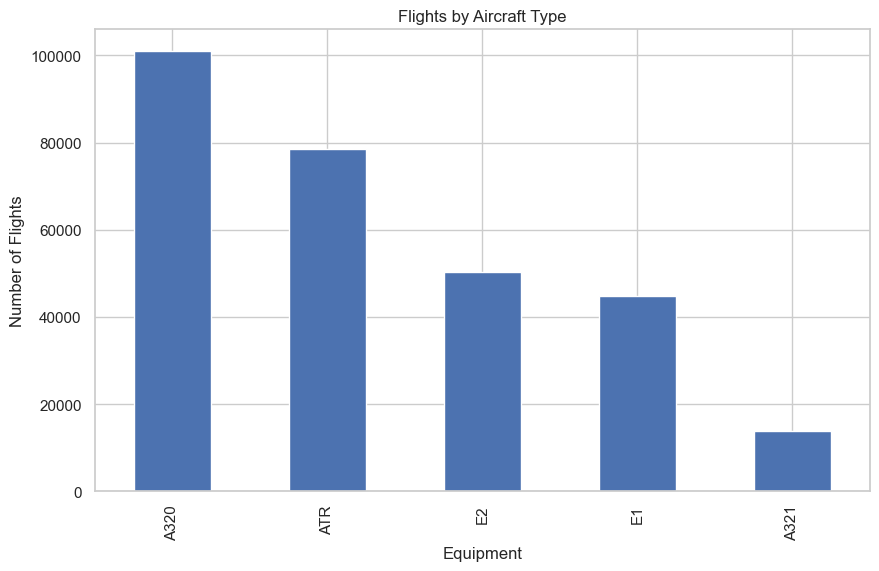

In [204]:
fleet_counts = df["Equipment"].value_counts()

fleet_counts.plot(kind="bar")
plt.title("Flights by Aircraft Type")
plt.ylabel("Number of Flights")
plt.show()

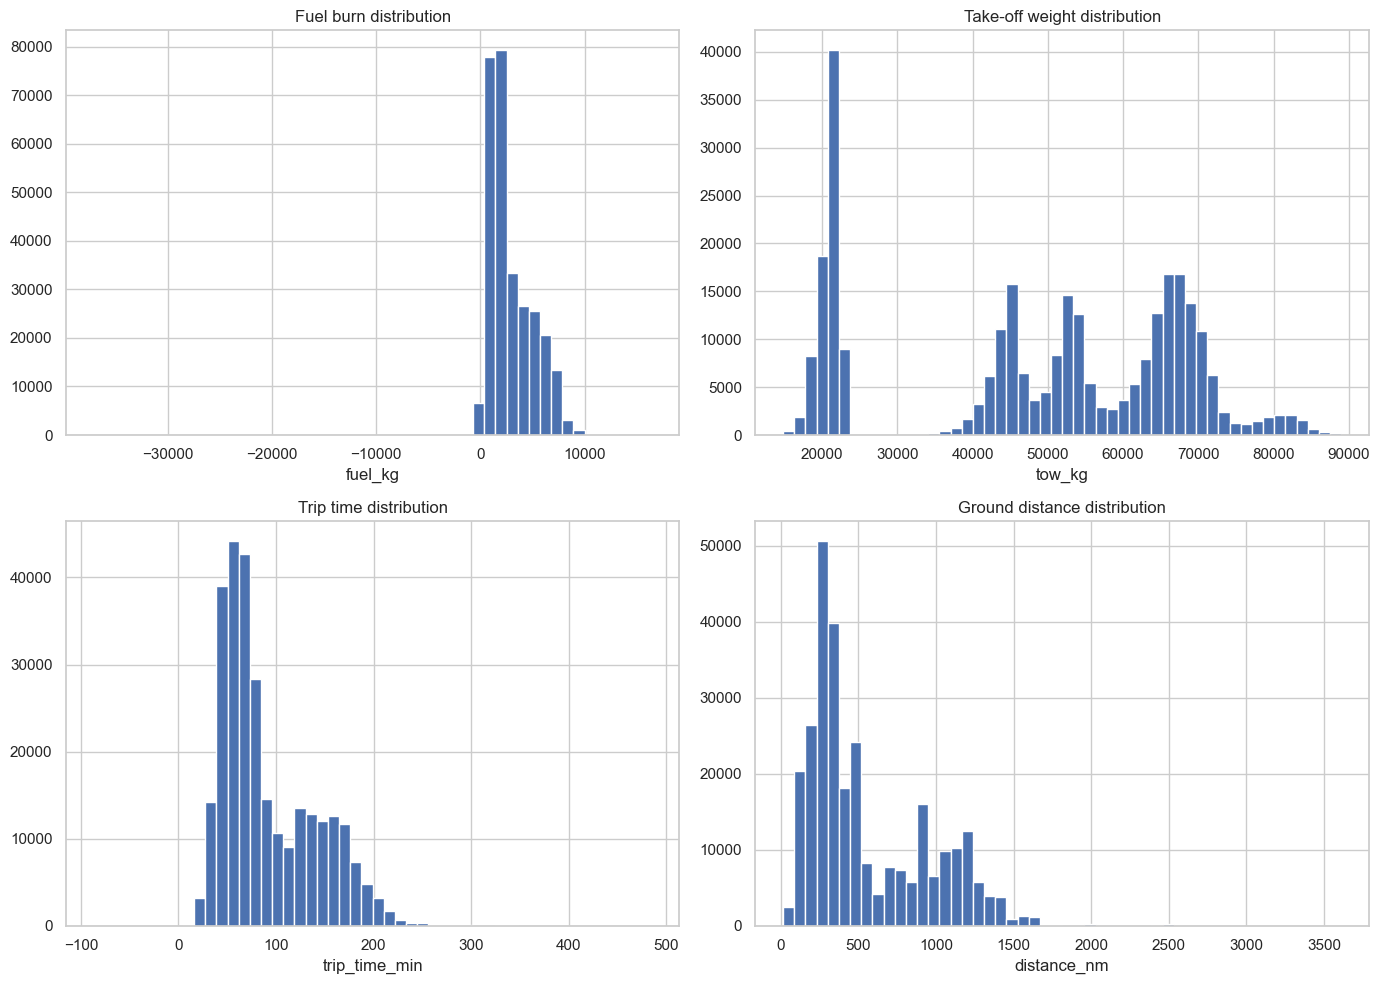

In [205]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["fuel_kg"], bins=50)
axes[0, 0].set_title("Fuel burn distribution")
axes[0, 0].set_xlabel("fuel_kg")

axes[0, 1].hist(df["tow_kg"], bins=50)
axes[0, 1].set_title("Take-off weight distribution")
axes[0, 1].set_xlabel("tow_kg")

axes[1, 0].hist(df["trip_time_min"], bins=50)
axes[1, 0].set_title("Trip time distribution")
axes[1, 0].set_xlabel("trip_time_min")

axes[1, 1].hist(df["distance_nm"], bins=50)
axes[1, 1].set_title("Ground distance distribution")
axes[1, 1].set_xlabel("distance_nm")

plt.tight_layout()
plt.show()

In [206]:
equipment_profile = (
    df.groupby("Equipment")
      .agg(
          flights=("FlightNumber", "count"),
          unique_routes=("route", "nunique"),
          tow_mean=("tow_kg", "mean"),
          tow_median=("tow_kg", "median"),
          trip_time_mean_min=("trip_time_min", "mean"),
          trip_time_median_min=("trip_time_min", "median"),
          distance_mean_nm=("distance_nm", "mean"),
          distance_median_nm=("distance_nm", "median"),
          fuel_mean_kg=("fuel_kg", "mean"),
          fuel_median_kg=("fuel_kg", "median")
      )
      .sort_values("distance_mean_nm")
)
equipment_profile

,flights,unique_routes,tow_mean,tow_median,trip_time_mean_min,trip_time_median_min,distance_mean_nm,distance_median_nm,fuel_mean_kg,fuel_median_kg
Equipment,,,,,,,,,,
ATR,78520,220,"20,881.07","21,225.00",62.80,62.00,231.28,231.00,671.55,660.00
E1,44816,269,"43,961.83","44,428.50",60.66,53.00,354.00,295.60,"2,252.26","1,994.00"
E2,50314,260,"52,455.81","52,743.00",78.58,64.00,491.27,382.80,"2,345.78","1,977.00"
A320,100893,294,"66,298.47","66,644.00",123.86,128.00,846.76,889.20,"4,495.91","4,529.00"
A321,13794,96,"79,301.27","80,116.50",165.62,167.00,"1,172.84","1,170.40","7,028.72","7,116.50"


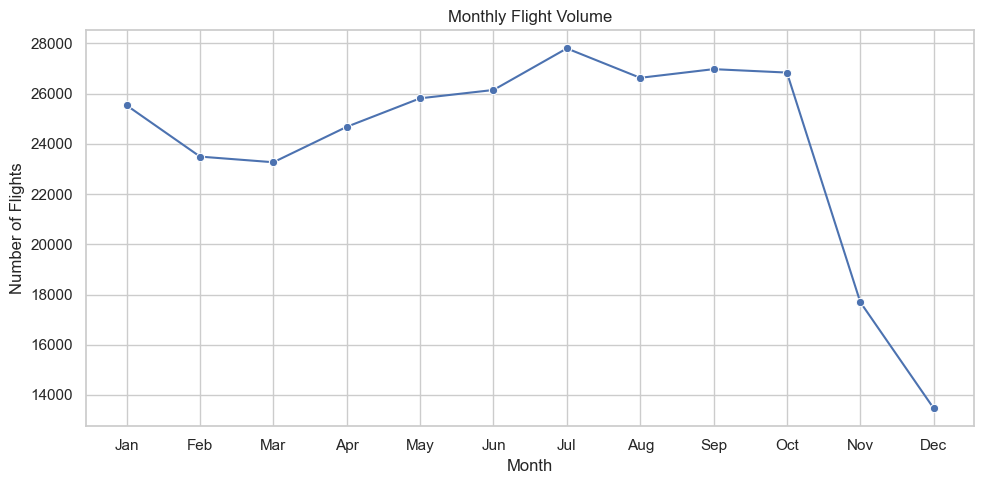

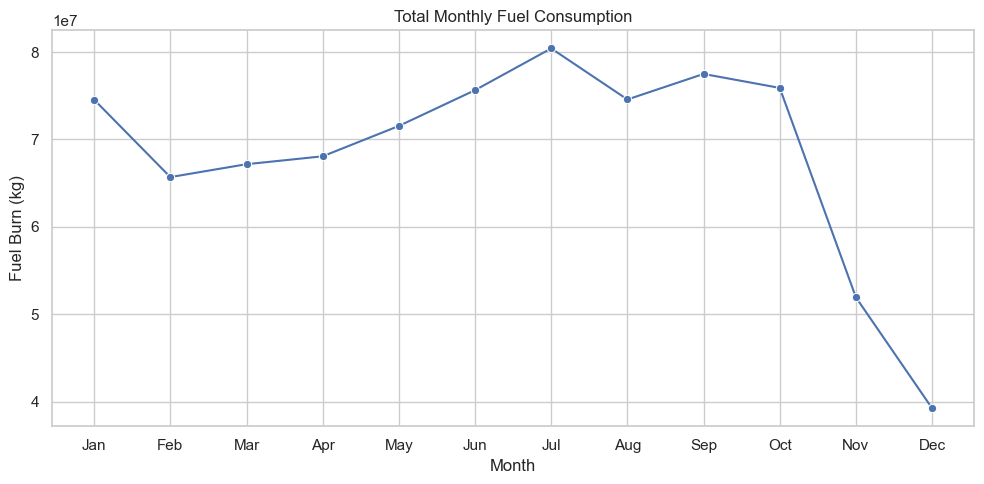

In [207]:
#seasonal variation
df["STDUTC"] = pd.to_datetime(df["STDUTC"])

df["month"] = df["STDUTC"].dt.month
df["month_name"] = df["STDUTC"].dt.strftime("%b")
monthly_flights = (
    df.groupby("month_name")
    .size()
    .reindex(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_flights.index,
    y=monthly_flights.values,
    marker="o"
)

plt.title("Monthly Flight Volume")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.tight_layout()
plt.show()
monthly_flights
monthly_fuel = (
    df.groupby("month_name")["fuel_kg"]
    .sum()
    .reindex(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_fuel.index,
    y=monthly_fuel.values,
    marker="o"
)

plt.title("Total Monthly Fuel Consumption")
plt.xlabel("Month")
plt.ylabel("Fuel Burn (kg)")

plt.tight_layout()
plt.show()


### Network structure and route concentration

After checking basic distributions, the next question is whether the dataset is concentrated around a few airports and recurring routes.  
That matters because later efficiency comparisons become more meaningful when there is route overlap between aircraft types.


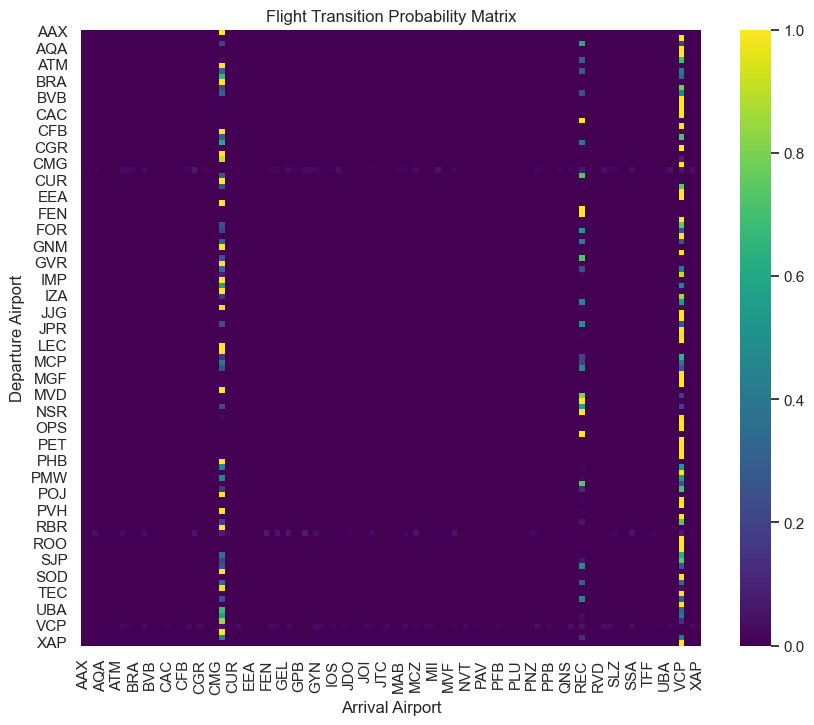

In [208]:
transition_counts = pd.crosstab(
    df["DepartureStation"],
    df["ArrivalStation"]
)
markov_matrix = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    markov_matrix,
    cmap="viridis"
)

plt.title("Flight Transition Probability Matrix")
plt.xlabel("Arrival Airport")
plt.ylabel("Departure Airport")

plt.show()


In [209]:
#establishing evidence for the hubs using Markov Matrix
P = markov_matrix.values

eigvals, eigvecs = np.linalg.eig(P.T)

stationary = np.real(eigvecs[:,np.isclose(eigvals,1)])

stationary = stationary / stationary.sum()

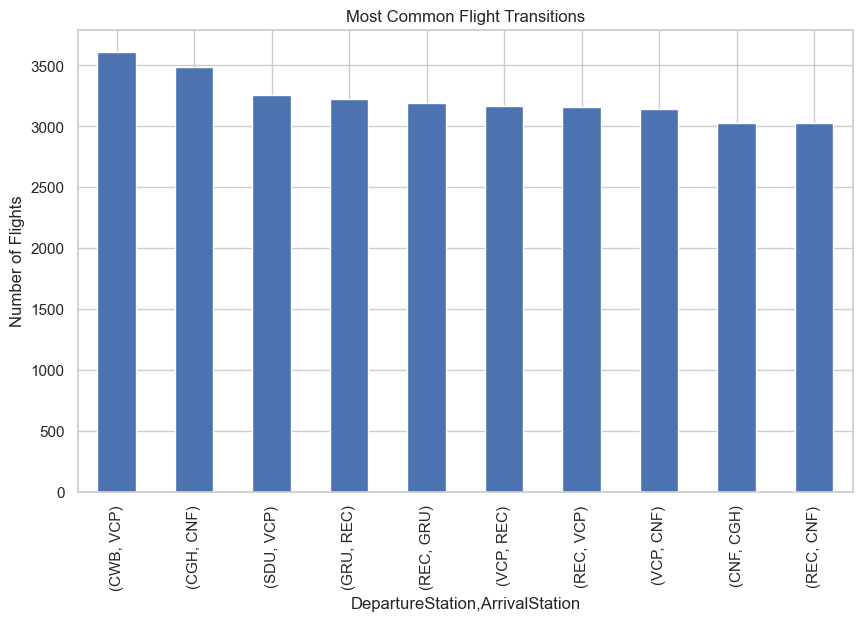

In [210]:
top_routes = transition_counts.stack().sort_values(ascending=False).head(10)

top_routes.plot(kind="bar")
plt.title("Most Common Flight Transitions")
plt.ylabel("Number of Flights")
plt.show()

## 2. Grouping similar aircraft

Once the sample coverage is clear, the next step is to define comparable aircraft families from their observed missions.

### Reasoning

The dataset does not include individual tail numbers, so the best available proxy for “similar airplanes” is the **equipment family** and its observed operating profile.

To group aircraft in a way that is useful for route and fuel analysis, we used the median values of:

- **take-off weight**
- **trip time**
- **ground distance**
- **fuel burn**

Standardizing those variables and checking clustering quality for a few values of **k**.  
With only five equipment families, the data naturally splits into **two broad groups**:

- lighter regional aircraft
- heavier Airbus narrowbodies

However, for business interpretation, **three groups** are more useful because they preserve the distinction between:

- **ATR turboprops**
- **Embraer regional jets**
- **Airbus narrowbodies**


In [211]:
cluster_features = equipment_profile[[
    "tow_median",
    "trip_time_median_min",
    "distance_median_nm",
    "fuel_median_kg"
]]

scaler = StandardScaler()
X = scaler.fit_transform(cluster_features)
OMP_NUM_THREADS = 1

silhouette_table = []
for k in range(2, 5):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X)
    silhouette_table.append({"k": k, "silhouette_score": silhouette_score(X, labels)})

pd.DataFrame(silhouette_table)

c:\Users\lcbrs\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lcbrs\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lcbrs\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,k,silhouette_score
0,2,0.62
1,3,0.44
2,4,0.26


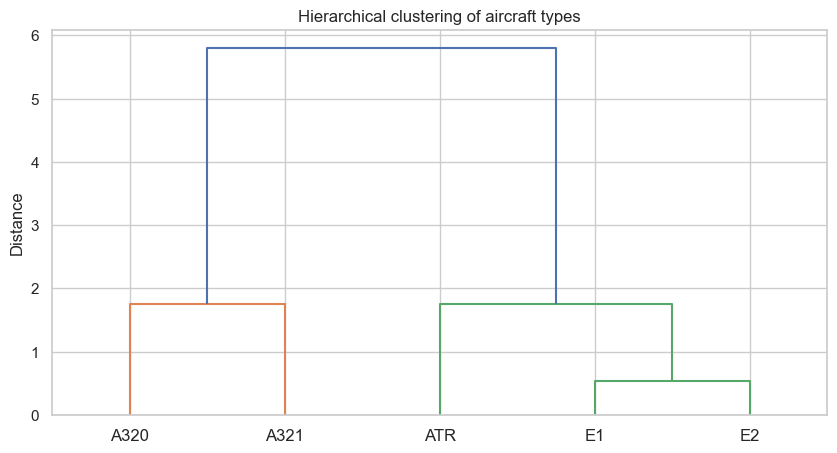

In [212]:
Z = linkage(X, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=cluster_features.index.tolist())
plt.title("Hierarchical clustering of aircraft types")
plt.ylabel("Distance")
plt.show()

In [213]:
raw_clusters = fcluster(Z, 3, criterion="maxclust")
clustered = equipment_profile.copy()
clustered["cluster_id"] = raw_clusters

# manual naming for interpretability after inspecting the profiles
cluster_name_map = {}
for equipment, cid in zip(clustered.index, clustered["cluster_id"]):
    if equipment == "ATR":
        cluster_name_map[cid] = "Regional turboprop"
    elif equipment in ["E1", "E2"]:
        cluster_name_map[cid] = "Regional jet / short-medium haul"
    elif equipment in ["A320", "A321"]:
        cluster_name_map[cid] = "Mainline narrowbody / medium-long haul"

clustered["operational_group"] = clustered["cluster_id"].map(cluster_name_map)
clustered = clustered.sort_values(["cluster_id", "distance_mean_nm"])
clustered

,flights,unique_routes,tow_mean,tow_median,trip_time_mean_min,trip_time_median_min,distance_mean_nm,distance_median_nm,fuel_mean_kg,fuel_median_kg,cluster_id,operational_group
Equipment,,,,,,,,,,,,
A320,100893,294,"66,298.47","66,644.00",123.86,128.00,846.76,889.20,"4,495.91","4,529.00",1,Mainline narrowbody / medium-long haul
A321,13794,96,"79,301.27","80,116.50",165.62,167.00,"1,172.84","1,170.40","7,028.72","7,116.50",1,Mainline narrowbody / medium-long haul
E1,44816,269,"43,961.83","44,428.50",60.66,53.00,354.00,295.60,"2,252.26","1,994.00",2,Regional jet / short-medium haul
E2,50314,260,"52,455.81","52,743.00",78.58,64.00,491.27,382.80,"2,345.78","1,977.00",2,Regional jet / short-medium haul
ATR,78520,220,"20,881.07","21,225.00",62.80,62.00,231.28,231.00,671.55,660.00,3,Regional turboprop


### Why these groups make sense

- **Regional turboprop**: ATR stands alone because it has much lower weight, shorter stage lengths, and much lower fuel burn. It is typically used on shorter regional sectors.
- **Regional jet / short-medium haul**: E1 and E2 are close to each other. They are heavier and faster than ATR, but still operate shorter routes than the Airbus family.
- **Mainline narrowbody / medium-long haul**: A320 and A321 cluster together because they operate the longest trips, at the highest weights, and with the highest fuel burn.

Those aircraft share similar **time, distance, and TOW ranges** and are more likely to be substitutes on similar routes.


In [214]:
group_summary = (
    clustered.groupby("operational_group")[[
        "flights",
        "unique_routes",
        "tow_median",
        "trip_time_median_min",
        "distance_median_nm",
        "fuel_median_kg"
    ]]
    .mean()
    .sort_values("distance_median_nm")
)
group_summary

,flights,unique_routes,tow_median,trip_time_median_min,distance_median_nm,fuel_median_kg
operational_group,,,,,,
Regional turboprop,"78,520.00",220.00,"21,225.00",62.00,231.00,660.00
Regional jet / short-medium haul,"47,565.00",264.50,"48,585.75",58.50,339.20,"1,985.50"
Mainline narrowbody / medium-long haul,"57,343.50",195.00,"73,380.25",147.50,"1,029.80","5,822.75"


## 3. Scatter plots with trend lines

After defining comparable aircraft groups, the next step is to inspect the main operational relationships visually.  
The sequence starts with **distance vs trip time**, then moves to how **fuel burn** changes with time and weight.

To keep plots readable, we used a sample for the scatter points and computed the trend line from the same sample.


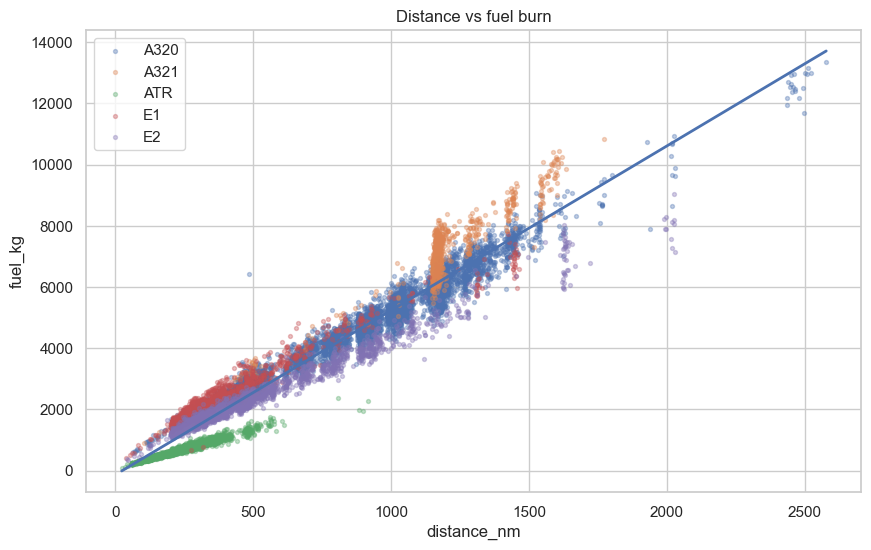

In [215]:
plot_sample = df.sample(n=min(15000, len(df)), random_state=RANDOM_STATE).copy()

def scatter_with_trend(data, x, y, title, by_equipment=False):
    plt.figure(figsize=(10, 6))

    if by_equipment:
        for equipment, g in data.groupby("Equipment"):
            plt.scatter(g[x], g[y], s=8, alpha=0.35, label=equipment)
        plt.legend()
    else:
        plt.scatter(data[x], data[y], s=8, alpha=0.35)

    coef = np.polyfit(data[x], data[y], 1)
    x_line = np.linspace(data[x].min(), data[x].max(), 200)
    y_line = coef[0] * x_line + coef[1]
    plt.plot(x_line, y_line, linewidth=2)

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

scatter_with_trend(plot_sample, "distance_nm", "fuel_kg", "Distance vs fuel burn", by_equipment=True)

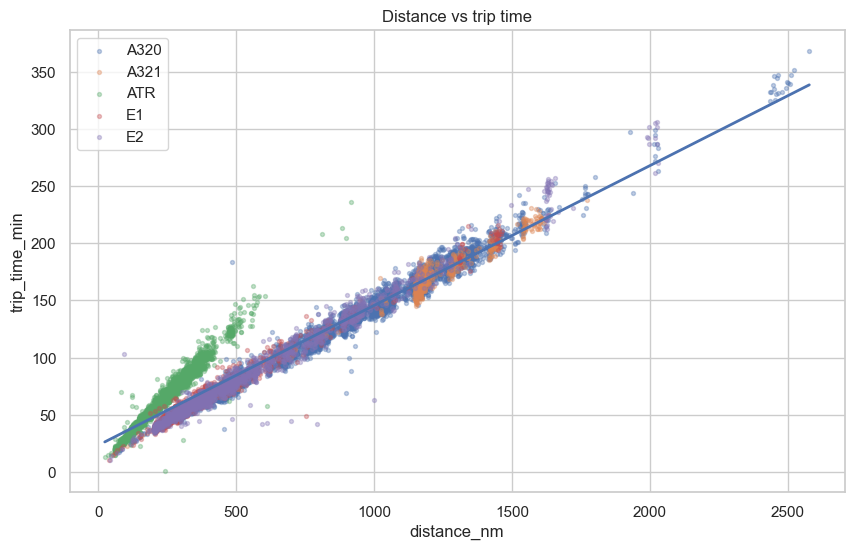

In [216]:
scatter_with_trend(plot_sample, "distance_nm", "trip_time_min", "Distance vs trip time", by_equipment=True)

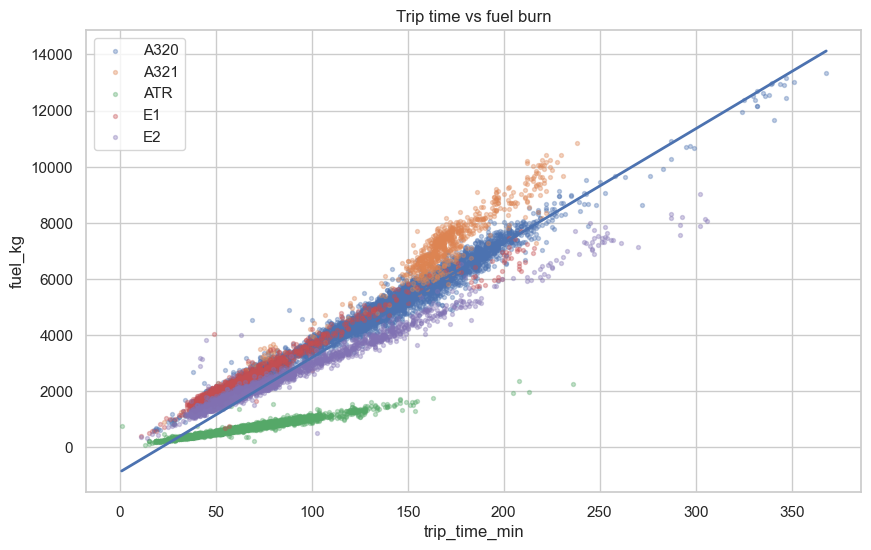

In [217]:
scatter_with_trend(plot_sample, "trip_time_min", "fuel_kg", "Trip time vs fuel burn", by_equipment=True)

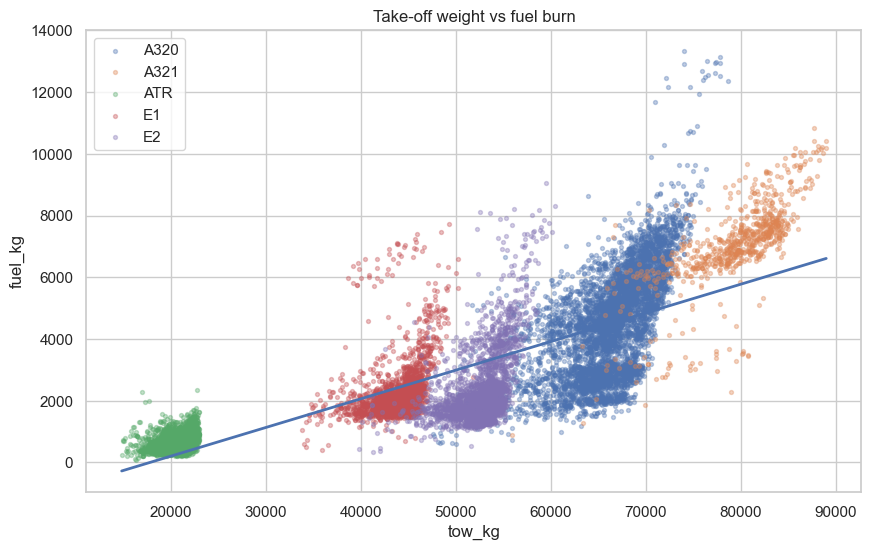

In [218]:
scatter_with_trend(plot_sample, "tow_kg", "fuel_kg", "Take-off weight vs fuel burn", by_equipment=True)

### First visual takeaways

The scatter plots provide the first visual evidence for what should be tested next with correlations:

- **Distance and trip time** should be very strongly related
- **Fuel burn** should rise strongly with both **distance** and **trip time**
- **Take-off weight** should also matter, but likely with more dispersion because route length and aircraft family influence fuel burn at the same time
- The colored scatter plots help show whether the same global trend holds within each aircraft family


### Equipment-level versions of the section 3 charts

The next cell recreates the three pairwise plots separately for each equipment type and adds a smooth tendency curve. This makes it easier to compare the operational profile of each aircraft family without the overlap from the full fleet view.

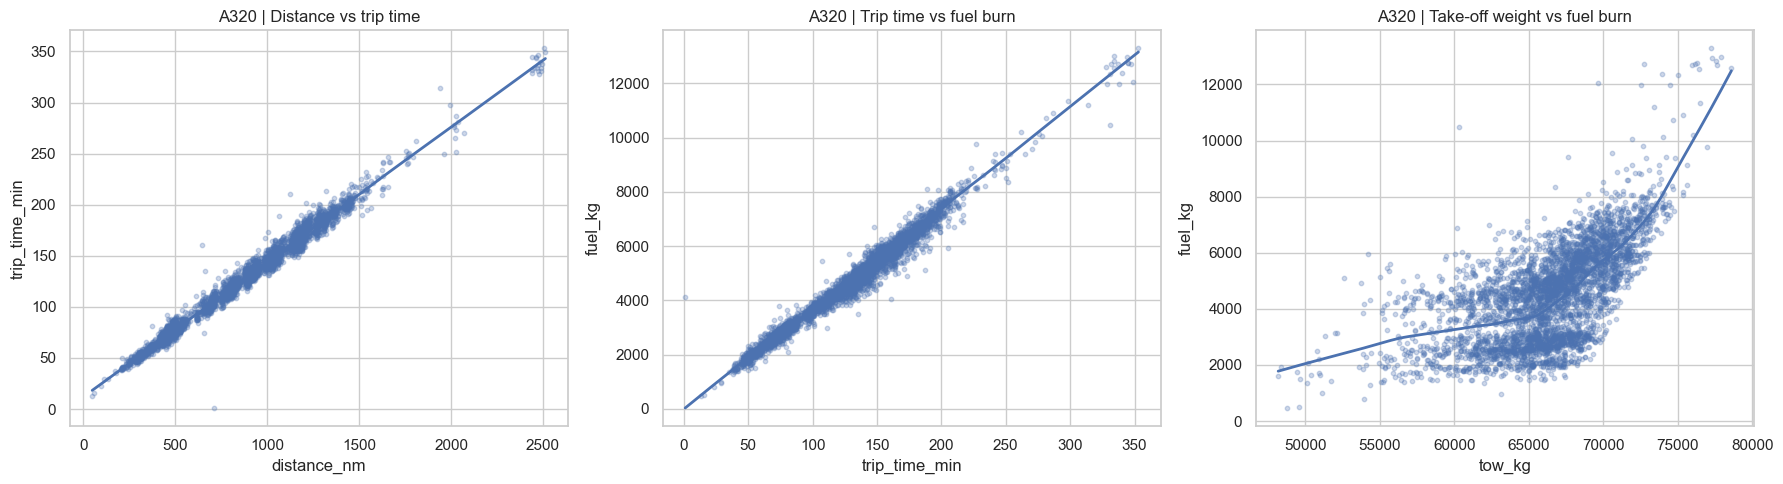

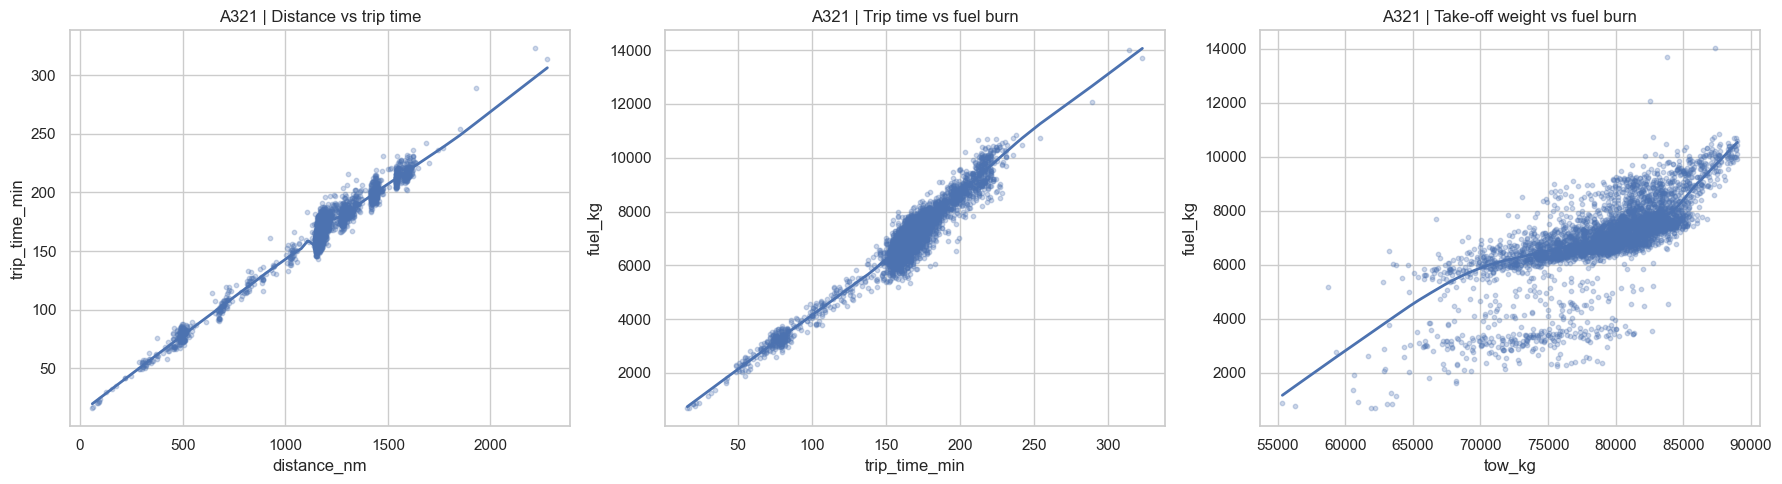

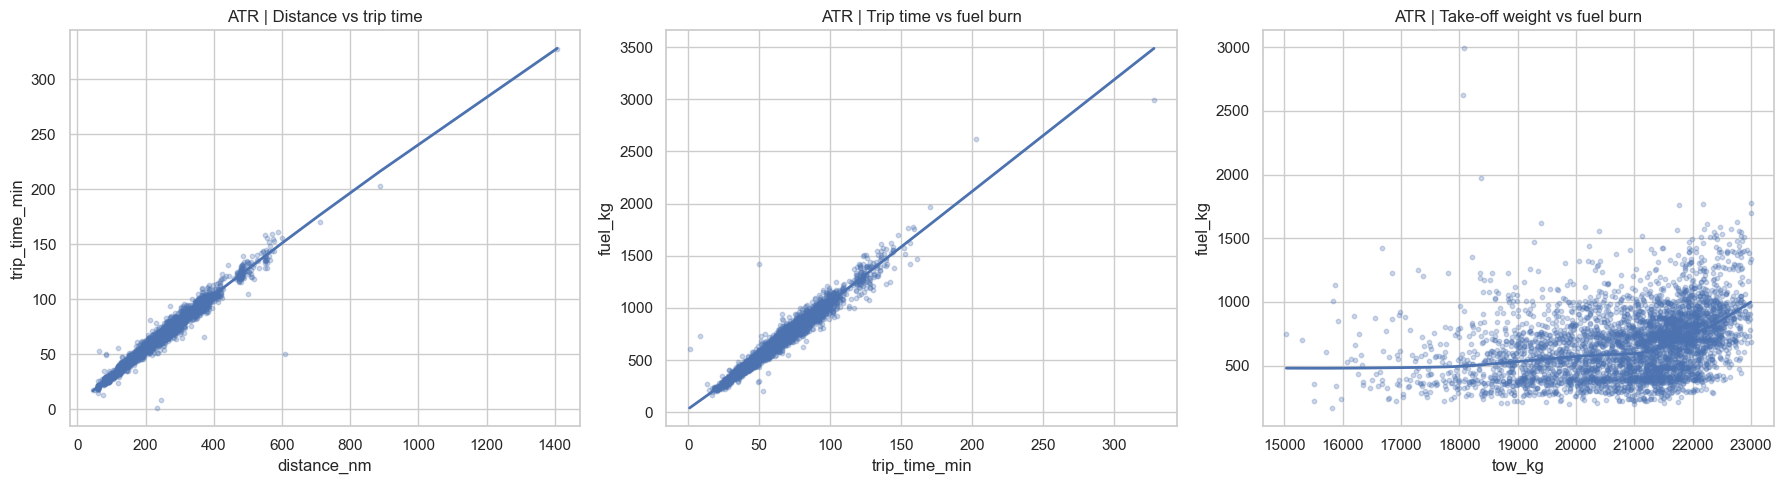

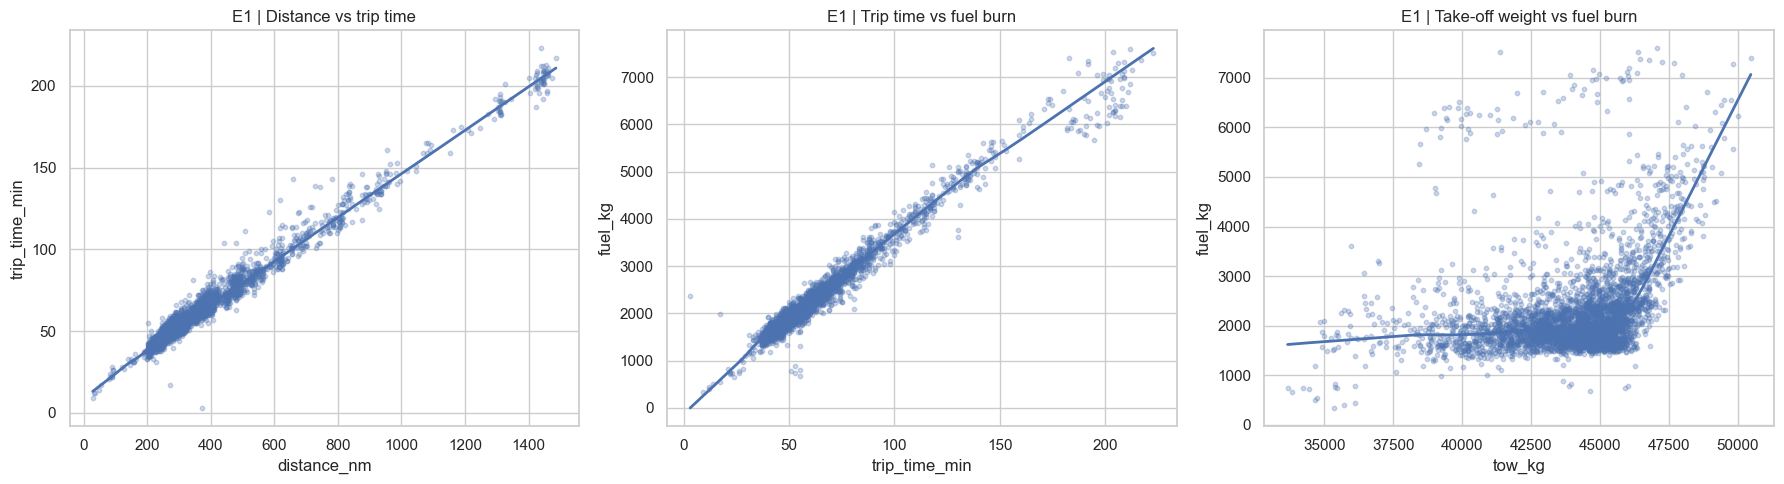

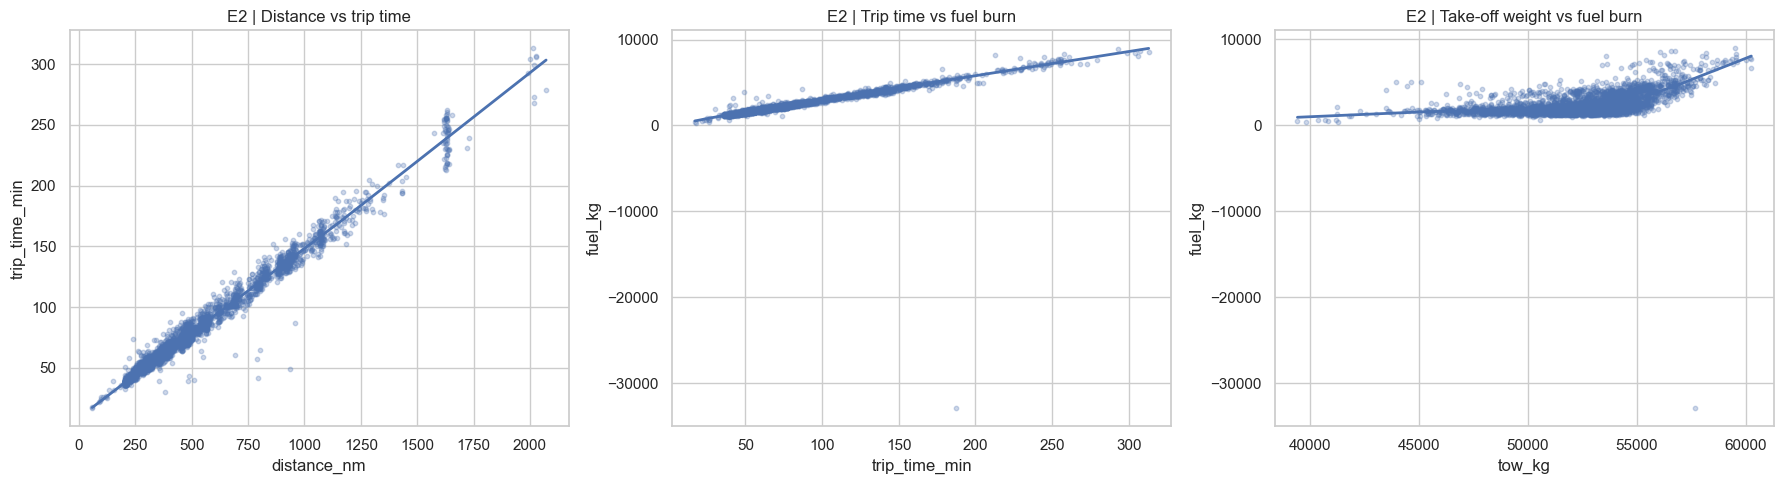

In [219]:
from statsmodels.nonparametric.smoothers_lowess import lowess

section3_pairs = [
    ("distance_nm", "trip_time_min", "Distance vs trip time"),
    ("trip_time_min", "fuel_kg", "Trip time vs fuel burn"),
    ("tow_kg", "fuel_kg", "Take-off weight vs fuel burn")
]

plot_vars = sorted({col for x, y, _ in section3_pairs for col in [x, y]})
plot_base = df.dropna(subset=plot_vars + ["Equipment"]).copy()


def plot_section3_by_equipment(data, equipment, pairs, sample_size=4000, frac=0.22):
    g = data[data["Equipment"] == equipment].copy()
    if len(g) > sample_size:
        g = g.sample(sample_size, random_state=RANDOM_STATE)

    fig, axes = plt.subplots(1, len(pairs), figsize=(18, 5))

    for ax, (x, y, title) in zip(axes, pairs):
        g2 = g[[x, y]].dropna().sort_values(x)
        ax.scatter(g2[x], g2[y], s=10, alpha=0.28)

        if len(g2) >= 50 and g2[x].nunique() > 10:
            smoothed = lowess(g2[y], g2[x], frac=frac, return_sorted=True)
            ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2)

        ax.set_title(f"{equipment} | {title}")
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()


for equipment in sorted(plot_base["Equipment"].unique()):
    plot_section3_by_equipment(plot_base, equipment, section3_pairs)


### Observed optimal operating windows by aircraft

To make "optimal conditions" measurable from the sample, the next cell defines a practical sweet spot for each aircraft as the **best 25% of flights in fuel burn per nautical mile** within that equipment type. This is not a manufacturer performance limit. It is the most efficient operating window observed in this dataset.

The table reports the median sweet-spot conditions and the interquartile range for distance, trip time, and take-off weight.

In [220]:
optimal_base = df[
    (df["fuel_kg"] > 0) &
    (df["trip_time_min"] > 0) &
    (df["distance_nm"] > 0) &
    (df["tow_kg"] > 0)
].copy()

optimal_base["fuel_per_nm"] = optimal_base["fuel_kg"] / optimal_base["distance_nm"]
optimal_base["fuel_per_min"] = optimal_base["fuel_kg"] / optimal_base["trip_time_min"]

optimal_rows = []

for equipment, g in optimal_base.groupby("Equipment"):
    threshold = g["fuel_per_nm"].quantile(0.25)
    best = g[g["fuel_per_nm"] <= threshold].copy()

    optimal_rows.append({
        "Equipment": equipment,
        "Flights in sample": len(g),
        "Sweet spot distance (median NM)": round(best["distance_nm"].median(), 1),
        "Distance window (IQR NM)": f"{best['distance_nm'].quantile(0.25):.1f} to {best['distance_nm'].quantile(0.75):.1f}",
        "Sweet spot trip time (median min)": round(best["trip_time_min"].median(), 1),
        "Trip time window (IQR min)": f"{best['trip_time_min'].quantile(0.25):.1f} to {best['trip_time_min'].quantile(0.75):.1f}",
        "Sweet spot TOW (median kg)": round(best["tow_kg"].median(), 1),
        "TOW window (IQR kg)": f"{best['tow_kg'].quantile(0.25):.1f} to {best['tow_kg'].quantile(0.75):.1f}",
        "Median fuel per NM in sweet spot": round(best["fuel_per_nm"].median(), 2),
        "Median fuel per min in sweet spot": round(best["fuel_per_min"].median(), 2),
        "Improvement vs typical fuel per NM": f"{(1 - best['fuel_per_nm'].median() / g['fuel_per_nm'].median()) * 100:.1f}%"
    })

optimal_conditions = pd.DataFrame(optimal_rows).sort_values("Median fuel per NM in sweet spot")
optimal_conditions


,Equipment,Flights in sample,Sweet spot distance (median NM),Distance window (IQR NM),Sweet spot trip time (median min),Trip time window (IQR min),Sweet spot TOW (median kg),TOW window (IQR kg),Median fuel per NM in sweet spot,Median fuel per min in sweet spot,Improvement vs typical fuel per NM
2,ATR,78520,288.00,241.0 to 355.0,75.00,63.0 to 91.0,"20,639.00",19325.5 to 21634.0,2.69,10.22,9.1%
4,E2,50309,790.00,513.5 to 949.6,116.00,78.0 to 142.0,"53,399.00",51292.2 to 55182.0,4.36,28.82,12.5%
0,A320,100893,"1,033.00",899.3 to 1186.3,145.00,128.0 to 166.0,"65,568.50",62659.5 to 67665.0,4.88,34.72,9.3%
1,A321,13794,"1,167.10",1154.2 to 1179.1,160.00,156.0 to 166.0,"75,770.00",72660.0 to 78130.0,5.50,39.94,8.4%
3,E1,44816,465.60,364.7 to 649.5,73.00,60.0 to 99.0,"44,283.00",41644.8 to 46011.5,5.80,36.19,13.1%


### Quick interpretation of the observed sweet spots

ATR is the most fuel-efficient family per nautical mile in the sample and performs best on short sectors around **241 to 355 NM**. E2 is the next strongest jet profile and looks most efficient on medium sectors around **514 to 950 NM**. A320 reaches its best window on medium-long sectors around **899 to 1,186 NM**.

A321 also looks best on long sectors, but in this sample it is concentrated in a much narrower mission profile around **1,154 to 1,179 NM**. E1 improves materially on longer missions than its median profile, with the best window concentrated around **365 to 649 NM**.

Operationally, the pattern suggests a stage-length ladder: **ATR for short-haul, E1 for short-medium, E2 for medium, and A320/A321 for medium-long to long sectors**. The exact assignment should still be validated route by route, especially where airport constraints, payload, or network timing matter.

## 4. Correlation analysis

With the visual patterns established, this section quantifies them using **Pearson** and **Spearman** correlations on the full dataset and within each equipment family.


In [221]:
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")

print("Pearson correlation")
display(pearson_corr)

print("\nSpearman correlation")
display(spearman_corr)

Pearson correlation


,fuel_kg,tow_kg,trip_time_min,distance_nm
fuel_kg,1.00,0.83,0.92,0.97
tow_kg,0.83,1.00,0.62,0.74
trip_time_min,0.92,0.62,1.00,0.97
distance_nm,0.97,0.74,0.97,1.00



Spearman correlation


,fuel_kg,tow_kg,trip_time_min,distance_nm
fuel_kg,1.00,0.90,0.83,0.96
tow_kg,0.90,1.00,0.67,0.83
trip_time_min,0.83,0.67,1.00,0.93
distance_nm,0.96,0.83,0.93,1.00


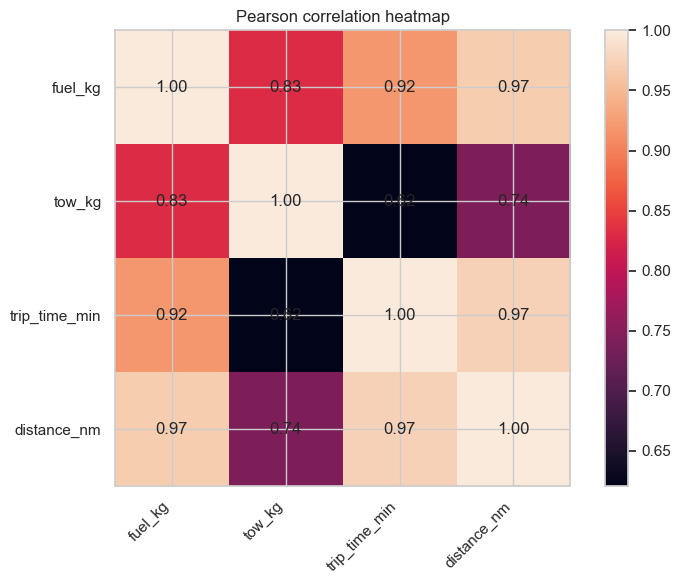

In [222]:
def plot_corr_heatmap(corr_df, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr_df.values)
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.index)
    ax.set_title(title)

    for i in range(corr_df.shape[0]):
        for j in range(corr_df.shape[1]):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_corr_heatmap(pearson_corr, "Pearson correlation heatmap")

In [223]:
fuel_corr_by_equipment = []
for equipment, g in df.groupby("Equipment"):
    row = {
        "Equipment": equipment,
        "fuel_vs_tow": g["fuel_kg"].corr(g["tow_kg"]),
        "fuel_vs_trip_time": g["fuel_kg"].corr(g["trip_time_min"]),
        "fuel_vs_distance": g["fuel_kg"].corr(g["distance_nm"]),
    }
    fuel_corr_by_equipment.append(row)

fuel_corr_by_equipment = pd.DataFrame(fuel_corr_by_equipment).sort_values("Equipment")
fuel_corr_by_equipment

,Equipment,fuel_vs_tow,fuel_vs_trip_time,fuel_vs_distance
0,A320,0.64,0.99,0.98
1,A321,0.72,0.96,0.94
2,ATR,0.33,0.98,0.98
3,E1,0.35,0.98,0.98
4,E2,0.51,0.95,0.95


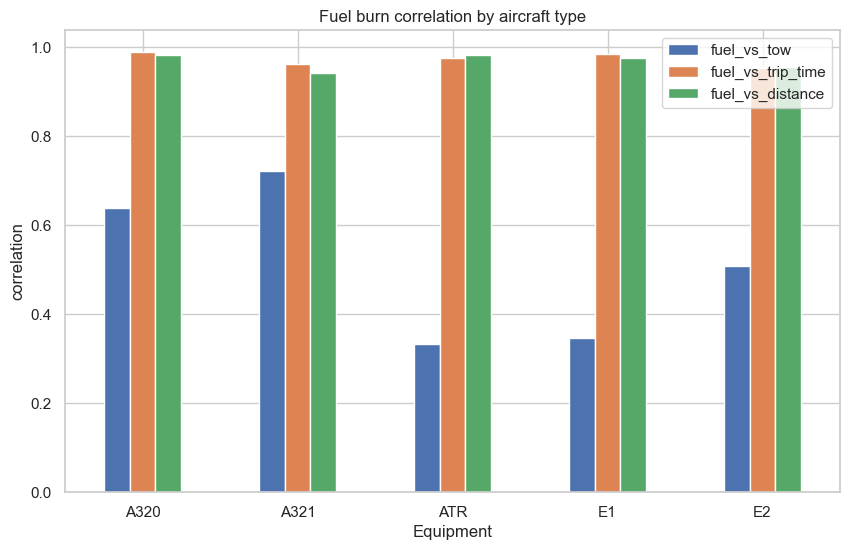

In [224]:
fuel_corr_plot = fuel_corr_by_equipment.set_index("Equipment")

fuel_corr_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Fuel burn correlation by aircraft type")
plt.ylabel("correlation")
plt.xticks(rotation=0)
plt.show()

### Interpreting the EDA before moving to efficiency

### What seems most correlated

On the full dataset, the strongest expected relationships should be:

1. **distance_nm ↔ trip_time_min**
2. **fuel_kg ↔ distance_nm**
3. **fuel_kg ↔ trip_time_min**

**tow_kg** should also correlate with **fuel_kg**, but usually less strongly than distance and time because different aircraft families fly different routes.

### What to watch out for

- **Distance** and **trip time** are probably close substitutes in a model, so using both in the same linear model may create multicollinearity.
- The overall correlation can be inflated by aircraft-family differences. That is why checking correlations **within each equipment type** is important.
- A good next step is to move from raw fuel burn to normalized metrics, such as:
  - fuel per nautical mile
  - fuel per minute
  - fuel per unit of weight
